In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Number of records:", df.shape[0])
print("Number of features:", df.shape[1])

Number of records: 891
Number of features: 12


In [ ]:
print("Feature names:")
print(df.columns.tolist())

Feature names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [ ]:
print("Data types:")
print(df.dtypes)

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

print("Input features:")
print(X.head())

print("\nTarget variable:")
print(y.head())

Input features:
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

Target variable:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [ ]:
numerical_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [ ]:
categorical_features = [
    "Sex",
    "Embarked"
]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [ ]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [ ]:
pipeline = Pipeline([
    ("preprocessing", preprocessor)
])

In [ ]:
X_train_processed = pipeline.fit_transform(X_train)

X_test_processed = pipeline.transform(X_test)

In [ ]:
print("Original training shape:", X_train.shape)
print("Original testing shape:", X_test.shape)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (712, 7)
Original testing shape: (179, 7)
Processed training shape: (712, 10)
Processed testing shape: (179, 10)


In [ ]:
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (712, 10)
Testing shape: (179, 10)


In [ ]:
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()

print(feature_names)
print("Number of features:", len(feature_names))

['numerical__Pclass' 'numerical__Age' 'numerical__SibSp'
 'numerical__Parch' 'numerical__Fare' 'categorical__Sex_female'
 'categorical__Sex_male' 'categorical__Embarked_C'
 'categorical__Embarked_Q' 'categorical__Embarked_S']
Number of features: 10


In [ ]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_train_processed_df.head()

,numerical__Pclass,numerical__Age,numerical__SibSp,numerical__Parch,numerical__Fare,categorical__Sex_female,categorical__Sex_male,categorical__Embarked_C,categorical__Embarked_Q,categorical__Embarked_S
0,0.829568,-0.081135,-0.465084,-0.466183,0.513812,0.0,1.0,0.0,0.0,1.0
1,-0.370945,-0.081135,-0.465084,-0.466183,-0.662563,0.0,1.0,0.0,0.0,1.0
2,-1.571457,-0.081135,-0.465084,-0.466183,3.955399,0.0,1.0,0.0,0.0,1.0
3,0.829568,-0.887827,-0.465084,0.727782,-0.467874,1.0,0.0,0.0,0.0,1.0
4,-0.370945,0.110934,0.478335,0.727782,-0.115977,1.0,0.0,0.0,0.0,1.0


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. Explore Dataset
print("Number of records:", df.shape[0])
print("Number of features:", df.shape[1])

print("\nFeature Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nStatistical Information:")
print(df.describe())

# 3. Remove duplicate records
df = df.drop_duplicates()

print("\nDuplicates after cleaning:")
print(df.duplicated().sum())

# 4. Select input features and target
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

# 5. Identify numerical and categorical features
numerical_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

# 6. Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 7. Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 8. Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# 9. ColumnTransformer
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# 10. Complete preprocessing pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor)
])

# 11. Apply preprocessing
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

# 12. Display shapes
print("\nOriginal Training Shape:", X_train.shape)
print("Original Testing Shape:", X_test.shape)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

# 13. Display processed feature names
feature_names = pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()

print("\nProcessed Feature Names:")
print(feature_names)

Number of records: 891
Number of features: 12

Feature Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Records:
0

Statistical Information:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
st

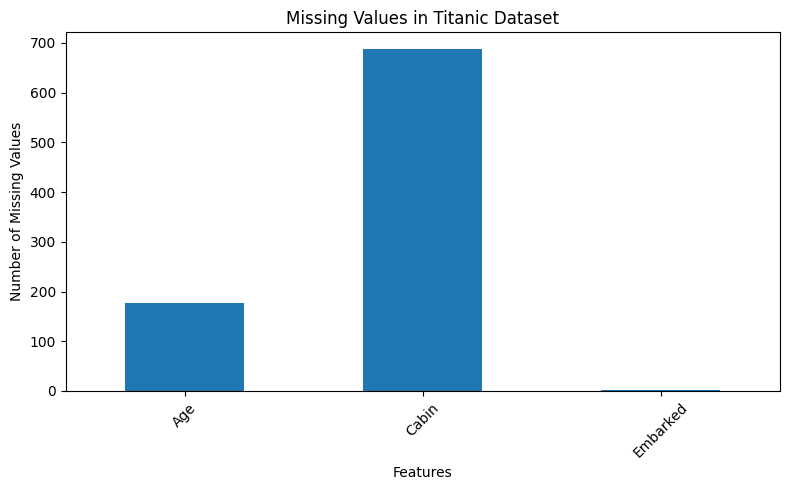

In [ ]:
import matplotlib.pyplot as plt

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(8, 5))
missing_values.plot(kind="bar")
plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

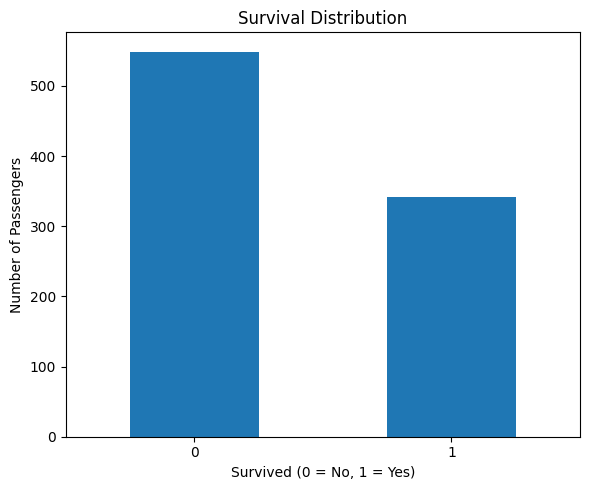

In [ ]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6, 5))
survival_counts.plot(kind="bar")
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

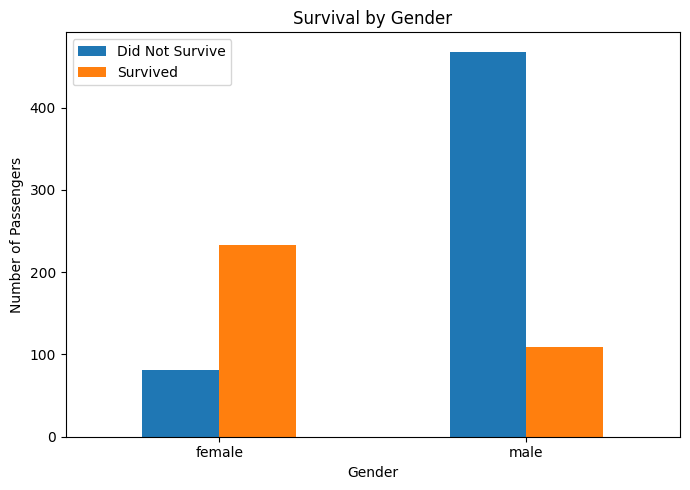

In [ ]:
gender_survival = pd.crosstab(df["Sex"], df["Survived"])

gender_survival.plot(kind="bar", figsize=(7, 5))

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])
plt.tight_layout()
plt.show()

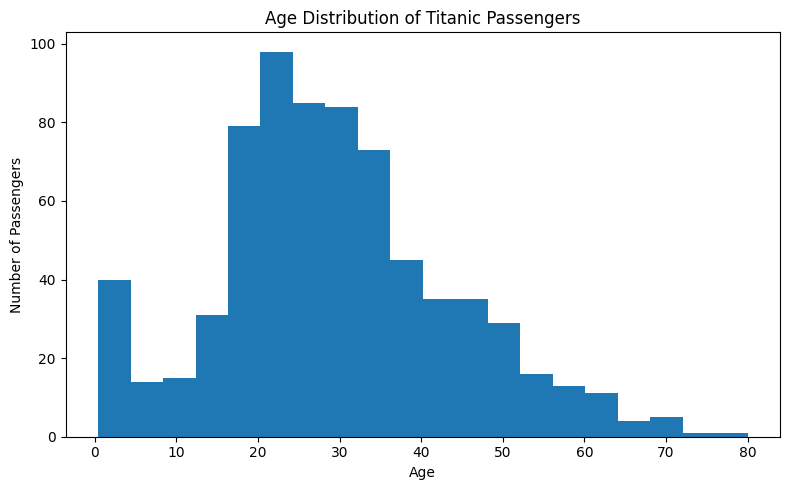

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"].dropna(), bins=20)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

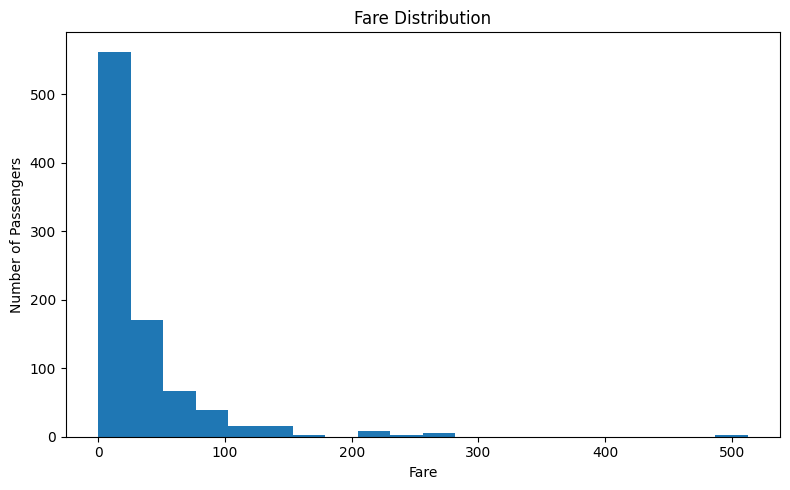

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["Fare"], bins=20)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
print("Number of records:", df.shape[0])
print("Number of features:", df.shape[1])

Number of records: 1599
Number of features: 12


In [ ]:
print("Feature Names:")
print(df.columns.tolist())

Feature Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [ ]:
print("\nData Types:")
print(df.dtypes)


Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [ ]:
print("\nTarget Variable: quality")


Target Variable: quality


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [ ]:
print("\nNumber of Duplicate Records:")
print(df.duplicated().sum())


Number of Duplicate Records:
240


In [ ]:
print("Basic Statistical Information:")
df.describe()

Basic Statistical Information:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [ ]:
print("Duplicates before cleaning:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates before cleaning: 240
Duplicates after cleaning: 0


In [ ]:
print("Cleaned Dataset Shape:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Cleaned Dataset Shape: (1359, 12)

Missing Values After Cleaning:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [ ]:
X = df.drop("quality", axis=1)

y = df["quality"]

In [ ]:
print("Input Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Input Features:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
5            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
5                 13.0                  40.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
5    

In [ ]:
print("Input Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Input Features:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
5            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
5                 13.0                  40.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
5    

In [ ]:
feature_range = X.max() - X.min()

print("Feature Ranges:")
print(feature_range)

Feature Ranges:
fixed acidity            11.30000
volatile acidity          1.46000
citric acid               1.00000
residual sugar           14.60000
chlorides                 0.59900
free sulfur dioxide      71.00000
total sulfur dioxide    283.00000
density                   0.01362
pH                        1.27000
sulphates                 1.67000
alcohol                   6.50000
dtype: float64


In [ ]:
print("Overall minimum:", np.min(X.values))
print("Overall maximum:", np.max(X.values))

Overall minimum: 0.0
Overall maximum: 289.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training dataset shape:", X_train.shape)
print("Testing dataset shape:", X_test.shape)

Training dataset shape: (1087, 11)
Testing dataset shape: (272, 11)


In [ ]:
standard_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
X_train_standard = standard_pipeline.fit_transform(X_train)

X_test_standard = standard_pipeline.transform(X_test)

In [ ]:
X_train_standard = standard_pipeline.fit_transform(X_train)

X_test_standard = standard_pipeline.transform(X_test)

In [ ]:
minmax_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

In [ ]:
X_train_minmax = minmax_pipeline.fit_transform(X_train)

X_test_minmax = minmax_pipeline.transform(X_test)

In [ ]:
comparison = pd.DataFrame({
    "Original Alcohol": X_train["alcohol"].head(5).values,
    "Standardized Alcohol": X_train_standard[:5, X.columns.get_loc("alcohol")]
})

comparison

,Original Alcohol,Standardized Alcohol
0,12.6,1.984240
1,10.2,-0.215867
2,10.0,-0.399209
3,9.9,-0.490880
4,10.0,-0.399209


In [ ]:
comparison_acidity = pd.DataFrame({
    "Original Fixed Acidity": X_train["fixed acidity"].head(5).values,
    "Standardized Fixed Acidity": X_train_standard[:5, X.columns.get_loc("fixed acidity")]
})

comparison_acidity

,Original Fixed Acidity,Standardized Fixed Acidity
0,8.9,0.351623
1,6.6,-0.981548
2,6.8,-0.865620
3,7.4,-0.517836
4,7.8,-0.285980


In [ ]:
comparison_scaling = pd.DataFrame({
    "Original Alcohol": X_train["alcohol"].head(5).values,
    "StandardScaler": X_train_standard[:5, X.columns.get_loc("alcohol")],
    "MinMaxScaler": X_train_minmax[:5, X.columns.get_loc("alcohol")]
})

comparison_scaling

,Original Alcohol,StandardScaler,MinMaxScaler
0,12.6,1.984240,0.646154
1,10.2,-0.215867,0.276923
2,10.0,-0.399209,0.246154
3,9.9,-0.490880,0.230769
4,10.0,-0.399209,0.246154


In [ ]:
comparison_scaling = pd.DataFrame({
    "Original Alcohol": X_train["alcohol"].head(5).values,
    "StandardScaler": X_train_standard[:5, X.columns.get_loc("alcohol")],
    "MinMaxScaler": X_train_minmax[:5, X.columns.get_loc("alcohol")]
})

comparison_scaling

,Original Alcohol,StandardScaler,MinMaxScaler
0,12.6,1.984240,0.646154
1,10.2,-0.215867,0.276923
2,10.0,-0.399209,0.246154
3,9.9,-0.490880,0.230769
4,10.0,-0.399209,0.246154


In [ ]:
X_test_standard_df = pd.DataFrame(
    X_test_standard,
    columns=X.columns,
    index=X_test.index
)

X_test_standard_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
55,-0.343944,0.517338,-1.194658,0.933678,-0.106593,0.896271,-0.055555,0.591961,0.200156,-0.746237,-0.857565
1291,-0.054125,0.601441,-0.887420,-0.311698,-0.316290,0.896271,0.395101,-0.170479,-0.128400,0.519851,0.425831
1544,0.061803,-0.884392,0.802390,-0.165183,-0.506923,-0.362070,-0.836691,-0.642977,-0.916933,0.865147,0.700844
593,0.931263,-0.211562,1.570486,0.713906,0.084040,-0.652457,-0.115642,1.987978,-0.128400,-0.458489,-1.315921
1261,-1.155440,2.760106,-1.399484,-0.384955,-0.125657,0.121907,-0.686473,-1.249707,1.842934,-0.631138,0.700844


In [ ]:
X_train_minmax_df = pd.DataFrame(
    X_train_minmax,
    columns=X.columns,
    index=X_train.index
)

X_train_minmax_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1016,0.380531,0.154930,0.40,0.089041,0.093489,0.154930,0.077739,0.351689,0.456897,0.251497,0.646154
1519,0.176991,0.380282,0.08,0.116438,0.156928,0.183099,0.074205,0.483113,0.603448,0.149701,0.276923
452,0.194690,0.281690,0.03,0.054795,0.120200,0.239437,0.102473,0.494126,0.603448,0.179641,0.246154
847,0.247788,0.366197,0.16,0.061644,0.110184,0.154930,0.116608,0.560206,0.655172,0.221557,0.230769
58,0.283186,0.302817,0.18,0.095890,0.106845,0.225352,0.169611,0.545521,0.594828,0.155689,0.246154


In [ ]:
X_test_minmax_df = pd.DataFrame(
    X_test_minmax,
    columns=X.columns,
    index=X_test.index
)

X_test_minmax_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
55,0.274336,0.323944,0.04,0.198630,0.120200,0.338028,0.137809,0.567548,0.517241,0.119760,0.169231
1291,0.318584,0.334507,0.10,0.082192,0.101836,0.338028,0.190813,0.463289,0.474138,0.251497,0.384615
1544,0.336283,0.147887,0.43,0.095890,0.085142,0.154930,0.045936,0.398678,0.370690,0.287425,0.430769
593,0.469027,0.232394,0.58,0.178082,0.136895,0.112676,0.130742,0.758443,0.474138,0.149701,0.092308
1261,0.150442,0.605634,0.00,0.075342,0.118531,0.225352,0.063604,0.315712,0.732759,0.131737,0.430769


In [ ]:
print("Original Dataset Shape:", df.shape)

print("Original X Shape:", X.shape)

print("Training Dataset Shape:", X_train.shape)

print("Testing Dataset Shape:", X_test.shape)

print("Processed Training Shape:", X_train_standard.shape)

print("Processed Testing Shape:", X_test_standard.shape)

Original Dataset Shape: (1359, 12)
Original X Shape: (1359, 11)
Training Dataset Shape: (1087, 11)
Testing Dataset Shape: (272, 11)
Processed Training Shape: (1087, 11)
Processed Testing Shape: (272, 11)


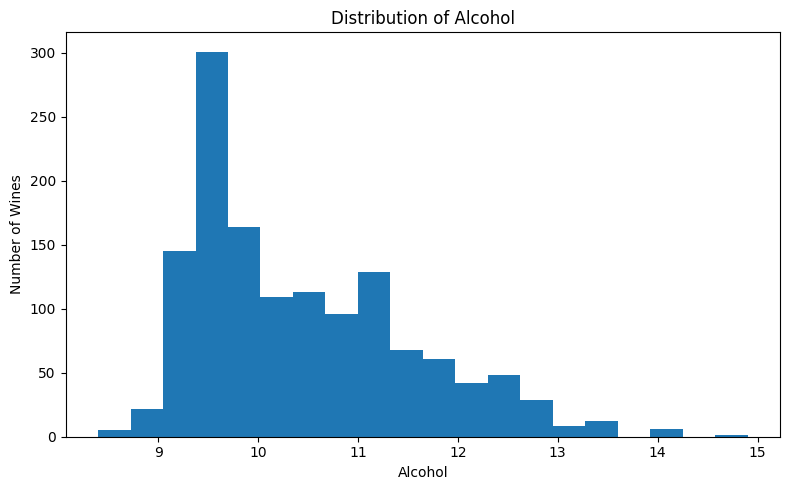

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["alcohol"], bins=20)

plt.title("Distribution of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Number of Wines")

plt.tight_layout()
plt.show()

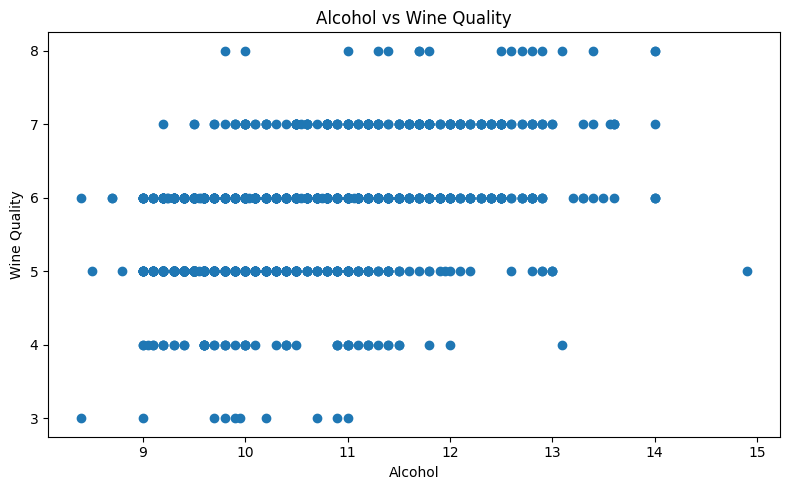

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["alcohol"], df["quality"])

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Wine Quality")

plt.tight_layout()
plt.show()

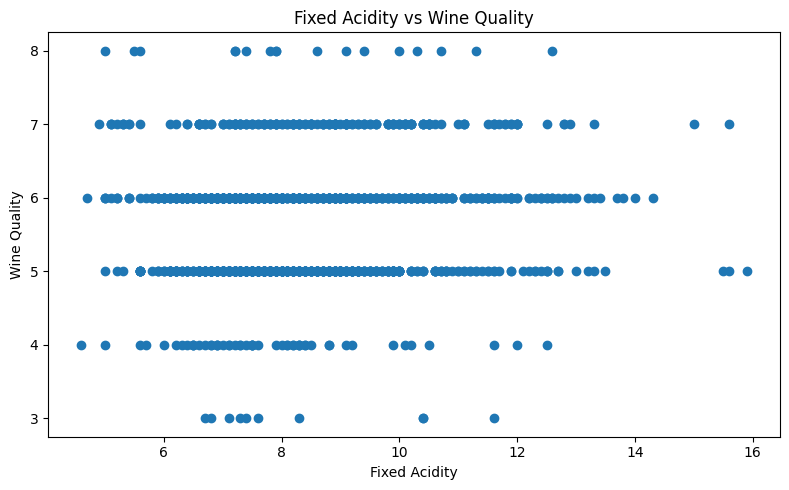

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["fixed acidity"], df["quality"])

plt.title("Fixed Acidity vs Wine Quality")
plt.xlabel("Fixed Acidity")
plt.ylabel("Wine Quality")

plt.tight_layout()
plt.show()

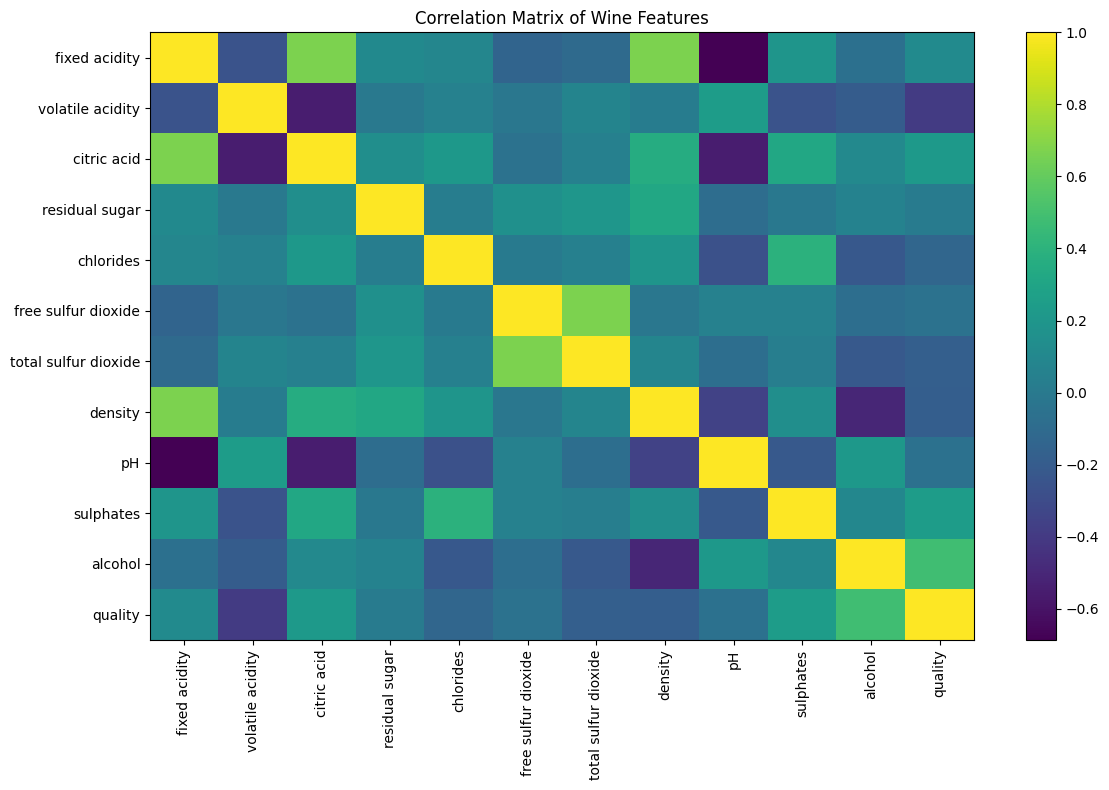

In [ ]:
correlation = df.corr()

plt.figure(figsize=(12, 8))

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Wine Features")

plt.tight_layout()
plt.show()

Dataset loaded successfully!

Number of Records: 1599
Number of Features: 12

Feature Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality   

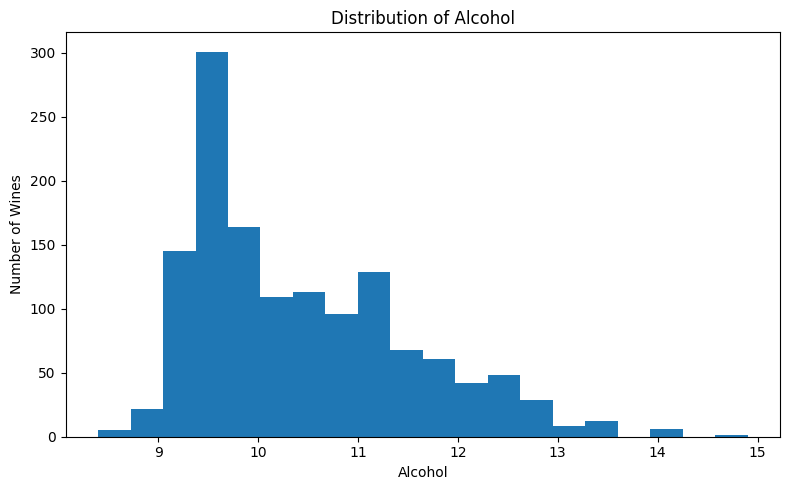

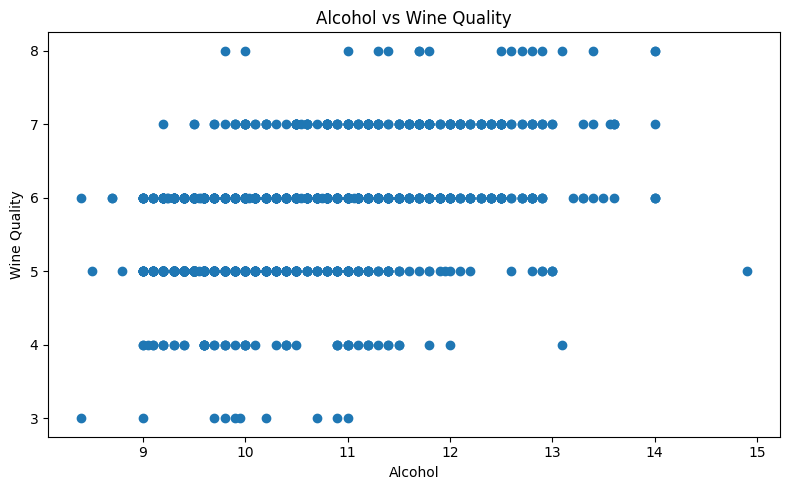

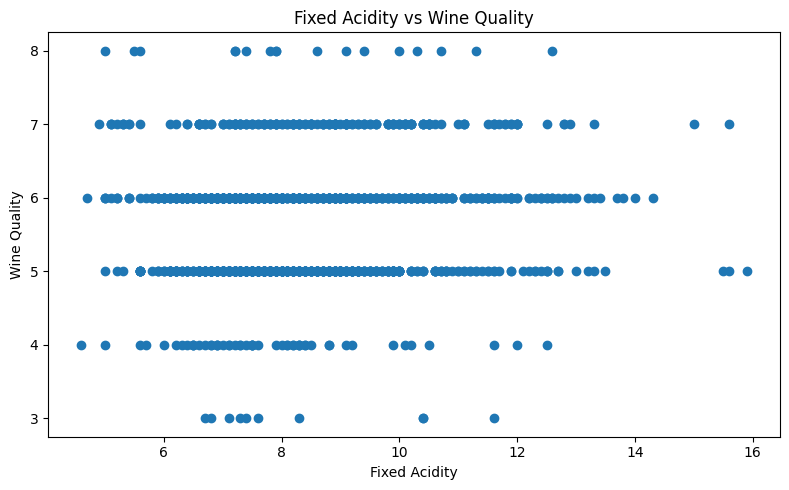

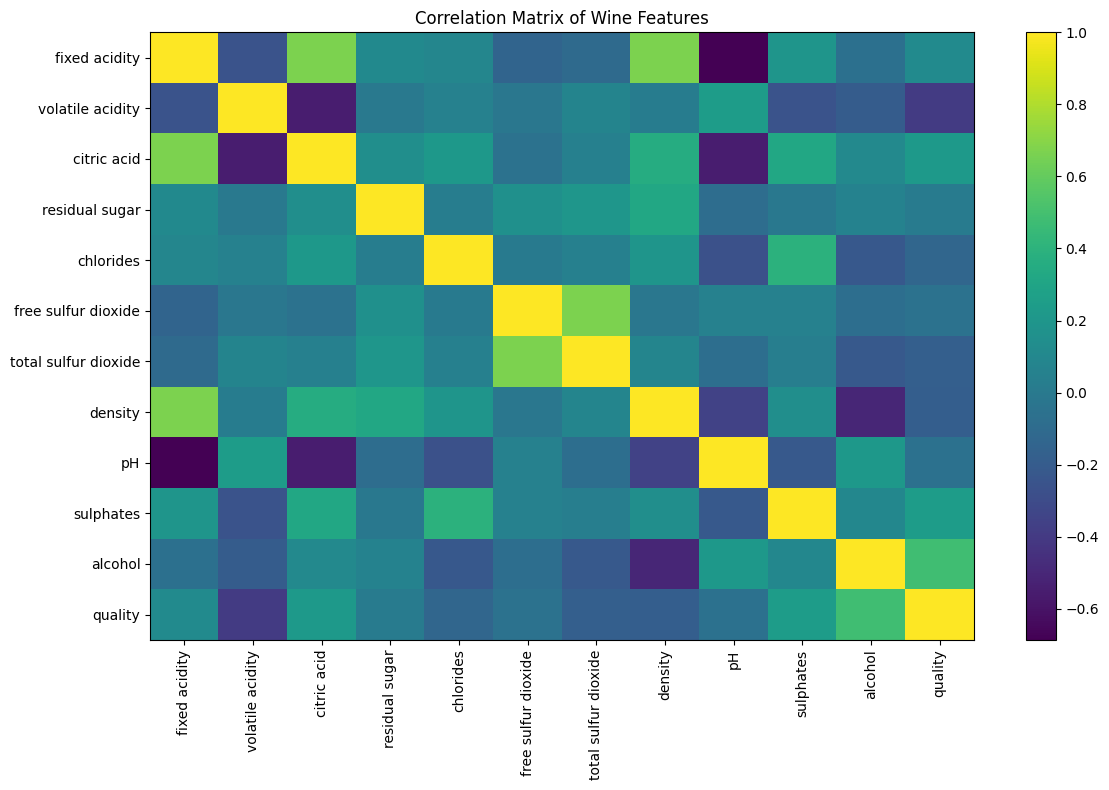

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ==========================================
# 1. Load Dataset
# ==========================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

print("Dataset loaded successfully!")

# ==========================================
# 2. Explore Dataset
# ==========================================

print("\nNumber of Records:", df.shape[0])
print("Number of Features:", df.shape[1])

print("\nFeature Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

# ==========================================
# 3. Statistical Information
# ==========================================

print("\nStatistical Information:")
print(df.describe())

# ==========================================
# 4. Data Cleaning
# ==========================================

print("\nDuplicates Before Cleaning:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After Cleaning:", df.duplicated().sum())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ==========================================
# 5. Input Features and Target
# ==========================================

X = df.drop("quality", axis=1)
y = df["quality"]

print("\nInput Features:")
print(X.columns.tolist())

print("\nTarget Variable: quality")

# ==========================================
# 6. Feature Ranges
# ==========================================

print("\nMinimum Values:")
print(X.min())

print("\nMaximum Values:")
print(X.max())

print("\nFeature Ranges:")
print(X.max() - X.min())

print("\nNumPy Minimum:", np.min(X.values))
print("NumPy Maximum:", np.max(X.values))

# ==========================================
# 7. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ==========================================
# 8. StandardScaler Pipeline
# ==========================================

standard_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_standard = standard_pipeline.fit_transform(X_train)
X_test_standard = standard_pipeline.transform(X_test)

# ==========================================
# 9. MinMaxScaler Pipeline
# ==========================================

minmax_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

X_train_minmax = minmax_pipeline.fit_transform(X_train)
X_test_minmax = minmax_pipeline.transform(X_test)

# ==========================================
# 10. Display Processed Data
# ==========================================

X_train_standard_df = pd.DataFrame(
    X_train_standard,
    columns=X.columns,
    index=X_train.index
)

X_test_standard_df = pd.DataFrame(
    X_test_standard,
    columns=X.columns,
    index=X_test.index
)

print("\nProcessed Training Data:")
print(X_train_standard_df.head())

print("\nProcessed Testing Data:")
print(X_test_standard_df.head())

# ==========================================
# 11. Compare Original and Scaled Values
# ==========================================

comparison = pd.DataFrame({
    "Original Alcohol": X_train["alcohol"].head(5).values,
    "StandardScaler": X_train_standard[:5, X.columns.get_loc("alcohol")],
    "MinMaxScaler": X_train_minmax[:5, X.columns.get_loc("alcohol")]
})

print("\nOriginal vs Transformed Alcohol:")
print(comparison)

# ==========================================
# 12. Shapes
# ==========================================

print("\nOriginal Dataset Shape:", df.shape)
print("Training Dataset Shape:", X_train.shape)
print("Testing Dataset Shape:", X_test.shape)
print("Processed Training Shape:", X_train_standard.shape)
print("Processed Testing Shape:", X_test_standard.shape)

# ==========================================
# 13. Graph 1 - Alcohol Distribution
# ==========================================

plt.figure(figsize=(8, 5))

plt.hist(df["alcohol"], bins=20)

plt.title("Distribution of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Number of Wines")

plt.tight_layout()
plt.show()

# ==========================================
# 14. Graph 2 - Alcohol vs Quality
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(df["alcohol"], df["quality"])

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Wine Quality")

plt.tight_layout()
plt.show()

# ==========================================
# 15. Graph 3 - Acidity vs Quality
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(df["fixed acidity"], df["quality"])

plt.title("Fixed Acidity vs Wine Quality")
plt.xlabel("Fixed Acidity")
plt.ylabel("Wine Quality")

plt.tight_layout()
plt.show()

# ==========================================
# 16. Correlation Heatmap
# ==========================================

correlation = df.corr()

plt.figure(figsize=(12, 8))

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Wine Features")

plt.tight_layout()
plt.show()